# LSTM vs Ordinal RoBERTa Comparison on New Articles

This notebook compares the original LSTM baseline predictions with the updated ordinal RoBERTa predictions on the new-article scrape. It uses saved prediction files from both models, then builds source-level counts, matched-URL agreement metrics, and comparison charts.

Important caveat: the LSTM file contains 1,990 rows from repeated article pulls, while the RoBERTa report deduplicated the zip to 944 unique URLs. Source-count charts show each model's report as generated. Matched-article agreement uses one LSTM row per URL so the paired comparison is fair.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('/home/neogrendal')
LSTM_PREDICTIONS = ROOT / 'bias_lstm_model' / 'new_articles_predictions.csv'
ROBERTA_PREDICTIONS = ROOT / 'bias_ordinal_roberta_model' / 'new_articles_report' / 'new_articles_ordinal_roberta_predictions.csv'
OUTPUT_DIR = ROOT / 'bias_ordinal_roberta_model' / 'new_articles_report'

SOURCE_ORDER = ['BBC', 'ABC', 'CBC', 'FOX', 'AlJazeera', 'NPR']
BIAS_ORDER = ['center', 'left', 'right']


## 1. Load Predictions From Both Models

In [2]:
lstm = pd.read_csv(LSTM_PREDICTIONS)
roberta = pd.read_csv(ROBERTA_PREDICTIONS)

for frame in [lstm, roberta]:
    frame['url_key'] = frame['url'].fillna('').astype(str).str.strip().str.lower()
    frame['title_key'] = frame['title'].fillna('').astype(str).str.strip().str.lower()

print(f'LSTM prediction rows: {len(lstm):,}')
print(f'RoBERTa prediction rows: {len(roberta):,}')
print(f'LSTM unique URLs: {lstm["url_key"].nunique():,}')
print(f'RoBERTa unique URLs: {roberta["url_key"].nunique():,}')


LSTM prediction rows: 1,990
RoBERTa prediction rows: 944
LSTM unique URLs: 944
RoBERTa unique URLs: 944


## 2. Source-Level Prediction Counts

In [3]:
lstm_counts = (
    lstm.groupby(['source', 'predicted_bias']).size().unstack(fill_value=0)
    .reindex(SOURCE_ORDER).reindex(columns=BIAS_ORDER, fill_value=0)
)
roberta_counts = (
    roberta.groupby(['source', 'predicted_bias']).size().unstack(fill_value=0)
    .reindex(SOURCE_ORDER).reindex(columns=BIAS_ORDER, fill_value=0)
)
comparison_counts = pd.concat(
    [lstm_counts.add_prefix('lstm_'), roberta_counts.add_prefix('roberta_')], axis=1
).reset_index()
comparison_counts.to_csv(OUTPUT_DIR / 'lstm_roberta_source_bias_counts.csv', index=False)
comparison_counts


predicted_bias,source,lstm_center,lstm_left,lstm_right,roberta_center,roberta_left,roberta_right
,BBC,306,274,147,83,114,0
,ABC,245,102,70,110,36,4
,CBC,179,56,52,47,83,2
,FOX,96,133,30,43,22,194
,AlJazeera,142,43,35,81,72,2
,NPR,25,27,28,33,17,1


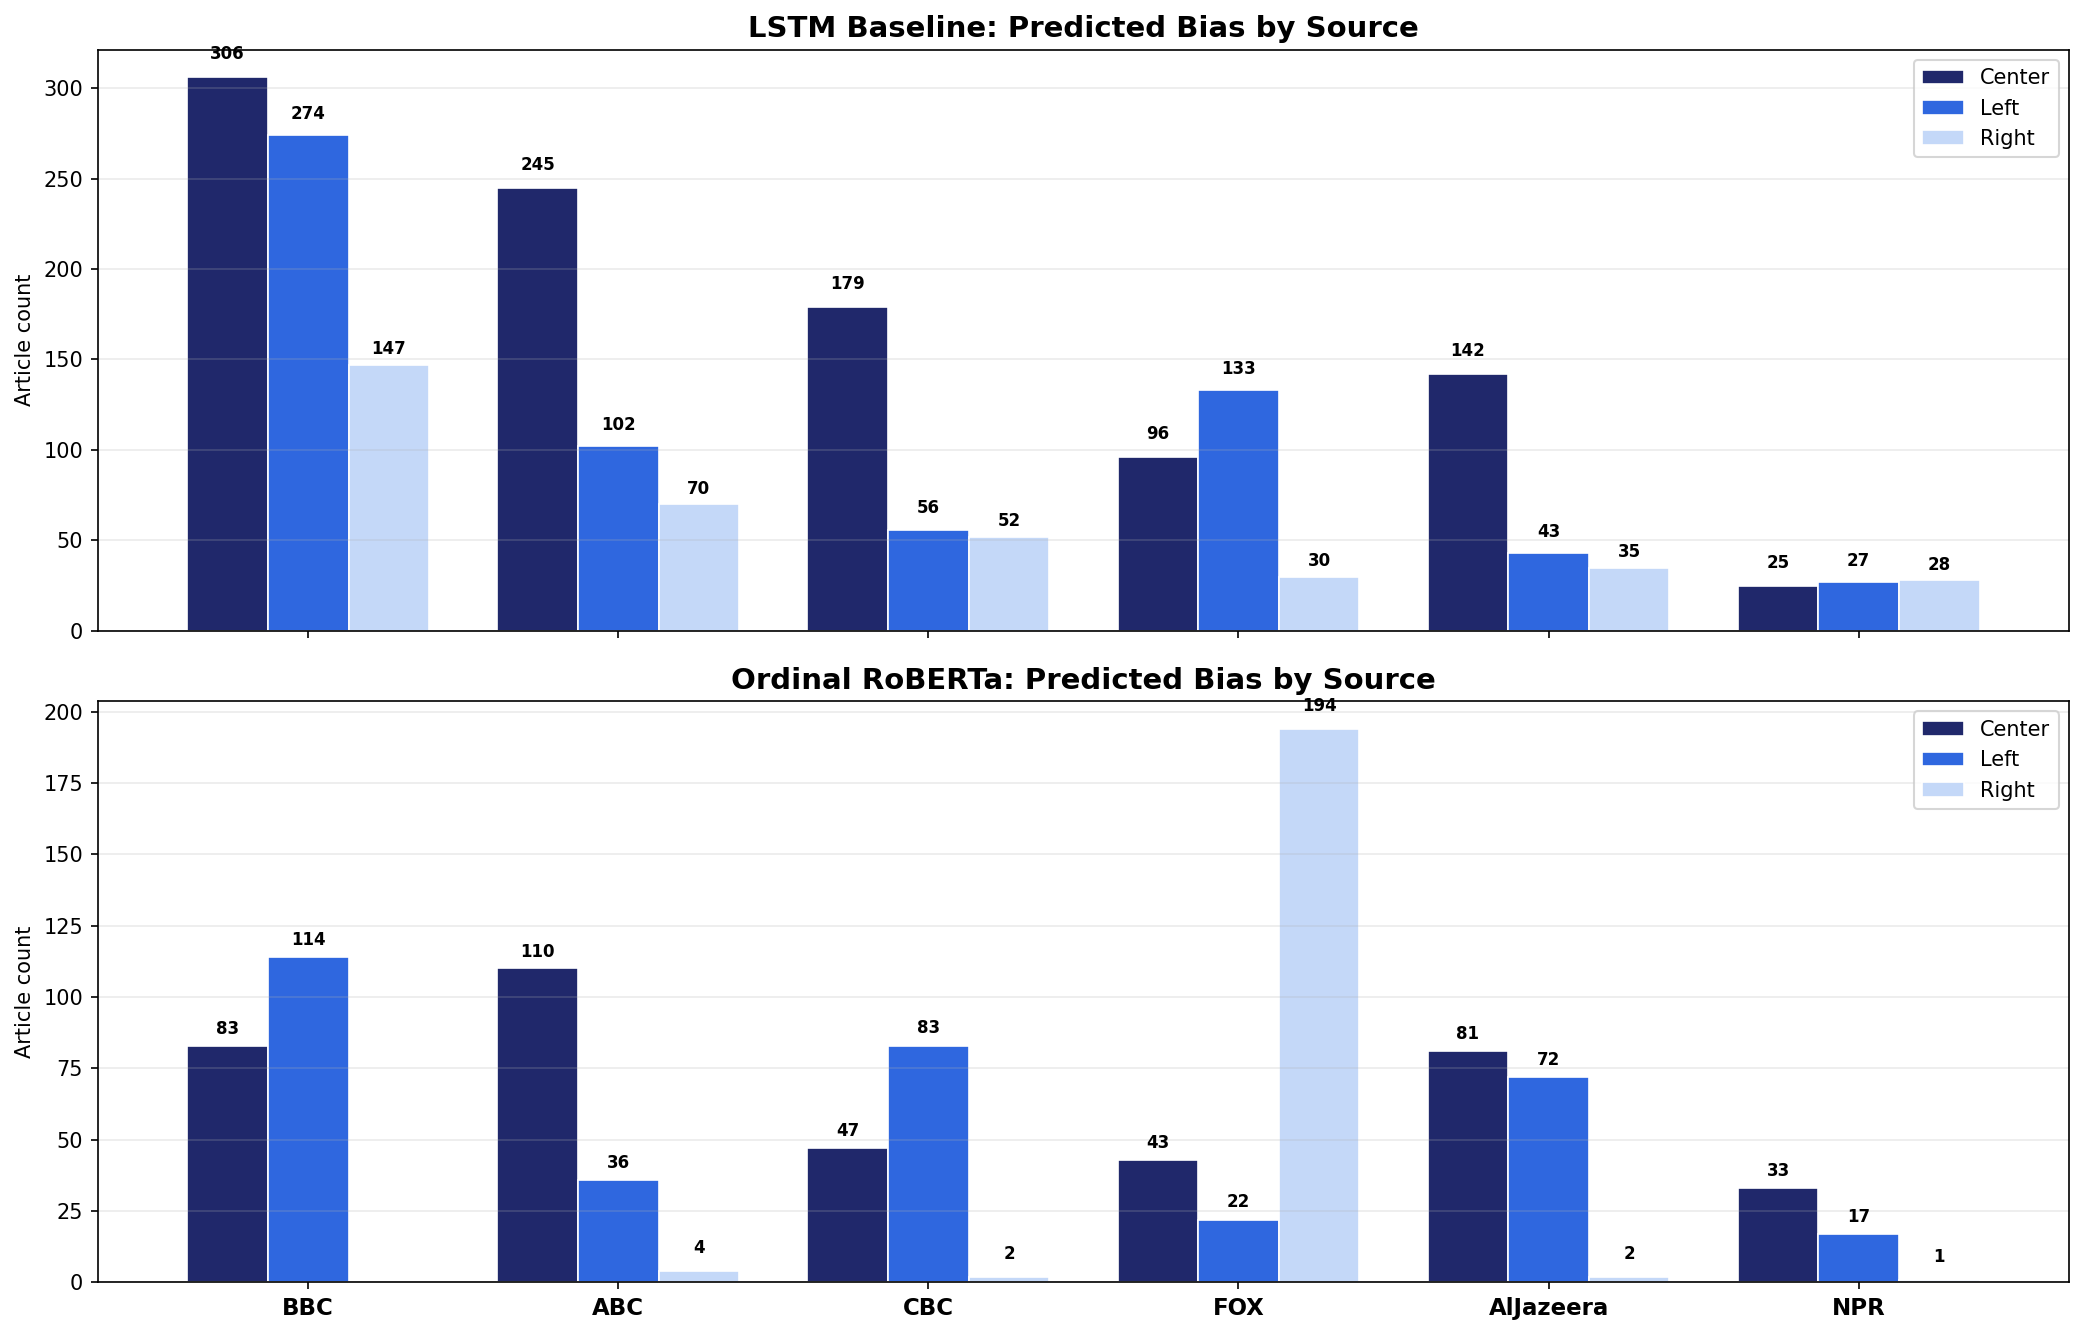

In [4]:
# Grouped source-count chart for both models.
colors = {'center': '#20286b', 'left': '#2f67df', 'right': '#c4d8f8'}
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
for ax, counts, title in [
    (axes[0], lstm_counts, 'LSTM Baseline: Predicted Bias by Source'),
    (axes[1], roberta_counts, 'Ordinal RoBERTa: Predicted Bias by Source'),
]:
    x = np.arange(len(SOURCE_ORDER))
    width = 0.26
    for offset, bias in zip([-width, 0, width], BIAS_ORDER):
        values = counts[bias].astype(int).values
        bars = ax.bar(x + offset, values, width, label=bias.title(), color=colors[bias], edgecolor='white', linewidth=0.8)
        for bar, value in zip(bars, values):
            if value:
                ax.text(bar.get_x() + bar.get_width() / 2, value + max(values.max(), 1) * 0.025, str(int(value)),
                        ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Article count')
    ax.grid(True, axis='y', alpha=0.25)
    ax.legend(loc='upper right')
axes[1].set_xticks(np.arange(len(SOURCE_ORDER)), SOURCE_ORDER, fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Matched URL Agreement

The LSTM prediction CSV contains repeated URLs from multiple article pulls. For direct model-to-model comparison, this section keeps the first LSTM prediction for each URL and joins it to the deduplicated RoBERTa predictions.


In [5]:
lstm_unique = lstm.sort_values('source_file').drop_duplicates('url_key', keep='first')
matched = lstm_unique[lstm_unique.url_key != ''].merge(
    roberta[roberta.url_key != ''],
    on='url_key',
    suffixes=('_lstm', '_roberta'),
    how='inner',
)
matched = matched.rename(columns={
    'source_lstm': 'source',
    'title_lstm': 'title',
    'url_lstm': 'url',
    'predicted_bias_lstm': 'lstm_predicted_bias',
    'predicted_bias_roberta': 'roberta_predicted_bias',
})
matched['models_agree'] = matched['lstm_predicted_bias'] == matched['roberta_predicted_bias']
matched['lstm_score'] = matched['lstm_predicted_bias'].map({'left': 0, 'center': 1, 'right': 2})
matched['roberta_score'] = matched['roberta_predicted_bias'].map({'left': 0, 'center': 1, 'right': 2})
matched['prediction_distance'] = (matched['lstm_score'] - matched['roberta_score']).abs()

matched_cols = ['source', 'title', 'url', 'lstm_predicted_bias', 'roberta_predicted_bias', 'models_agree', 'prediction_distance']
matched[matched_cols].to_csv(OUTPUT_DIR / 'lstm_roberta_matched_article_predictions.csv', index=False)

summary = pd.DataFrame([
    {'metric': 'LSTM rows', 'value': len(lstm)},
    {'metric': 'RoBERTa rows after deduplication', 'value': len(roberta)},
    {'metric': 'Matched unique URLs', 'value': len(matched)},
    {'metric': 'Matched article agreement rate', 'value': matched['models_agree'].mean()},
    {'metric': 'Matched article average prediction distance', 'value': matched['prediction_distance'].mean()},
])
summary


metric,value
LSTM rows,1990.000000
RoBERTa rows after deduplication,944.000000
Matched unique URLs,944.000000
Matched article agreement rate,0.365466
Matched article average prediction distance,0.806144


## 4. Transition Matrix and Source Agreement

In [6]:
transition = pd.crosstab(
    matched['lstm_predicted_bias'], matched['roberta_predicted_bias']
).reindex(index=BIAS_ORDER, columns=BIAS_ORDER, fill_value=0)
transition


roberta_predicted_bias,center,left,right
lstm_predicted_bias,,,
center,213,175,78
left,113,102,95
right,71,67,30


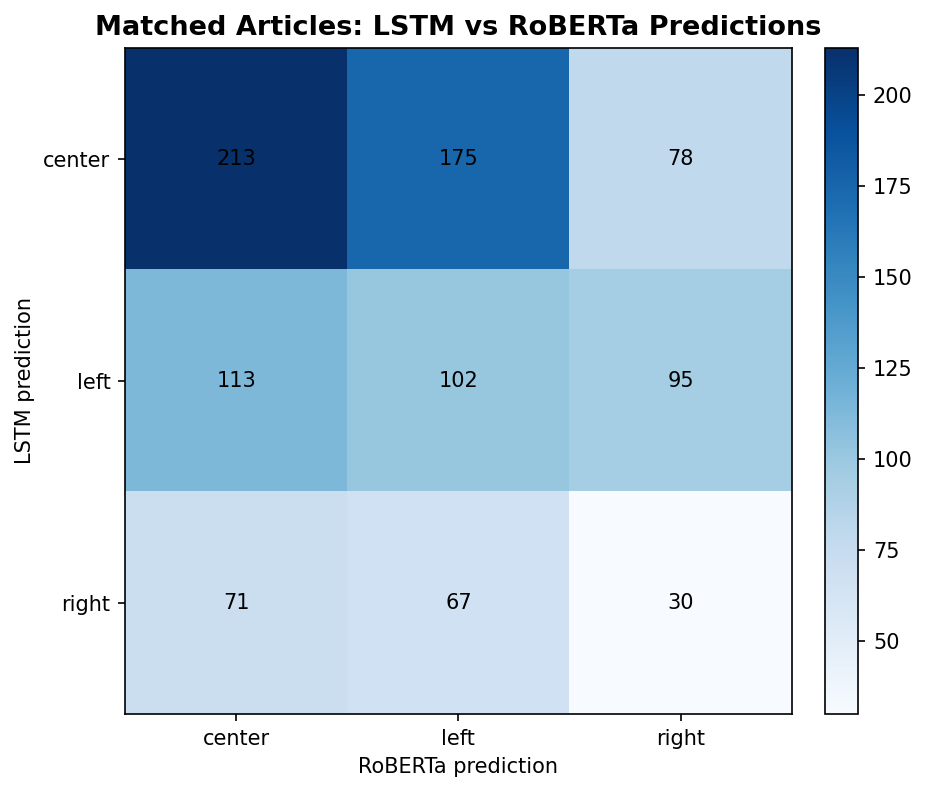

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 5.4))
im = ax.imshow(transition.values, cmap='Blues')
ax.set_title('Matched Articles: LSTM vs RoBERTa Predictions', fontsize=13, fontweight='bold')
ax.set_xlabel('RoBERTa prediction')
ax.set_ylabel('LSTM prediction')
ax.set_xticks(range(3), BIAS_ORDER)
ax.set_yticks(range(3), BIAS_ORDER)
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(int(transition.values[i, j])), ha='center', va='center', color='black')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


In [8]:
source_agreement = matched.groupby('source').agg(
    articles=('url_key', 'count'),
    agreement_rate=('models_agree', 'mean'),
    avg_prediction_distance=('prediction_distance', 'mean'),
).reindex(SOURCE_ORDER).reset_index()
source_agreement.to_csv(OUTPUT_DIR / 'lstm_roberta_source_agreement.csv', index=False)
source_agreement


source,articles,agreement_rate,avg_prediction_distance
BBC,197,0.401015,0.725888
ABC,150,0.546667,0.513333
CBC,132,0.340909,0.772727
FOX,259,0.227799,1.146718
AlJazeera,155,0.393548,0.677419
NPR,51,0.372549,0.725490


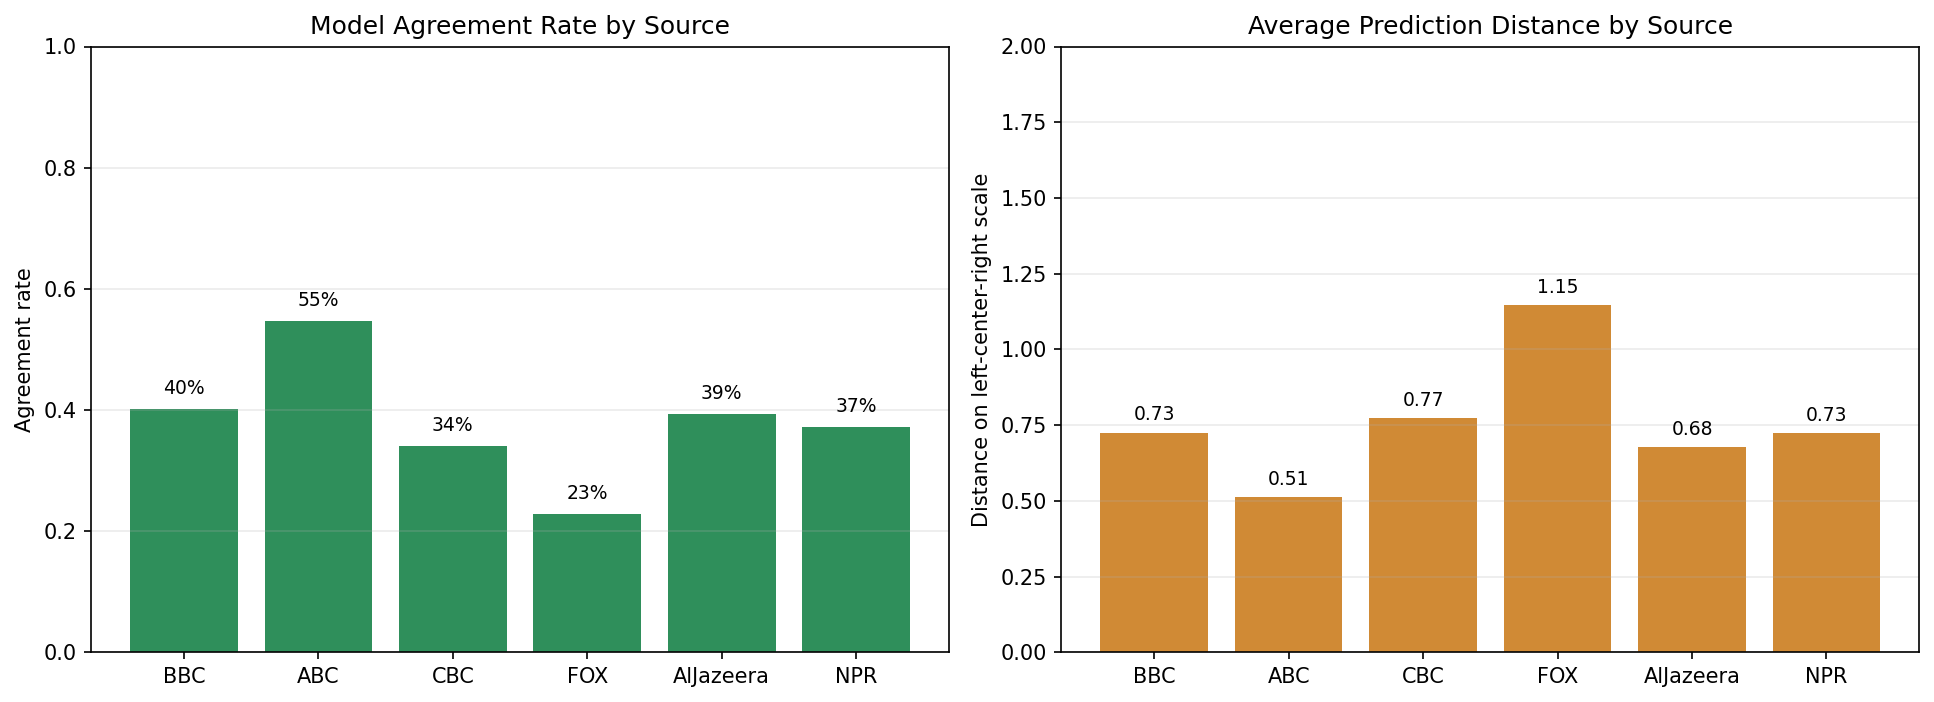

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].bar(source_agreement['source'], source_agreement['agreement_rate'], color='#2f8f5b')
axes[0].set_title('Model Agreement Rate by Source')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Agreement rate')
axes[0].grid(True, axis='y', alpha=0.25)
for idx, value in enumerate(source_agreement['agreement_rate']):
    axes[0].text(idx, value + 0.025, f'{value:.0%}', ha='center', fontsize=9)

axes[1].bar(source_agreement['source'], source_agreement['avg_prediction_distance'], color='#d08a35')
axes[1].set_title('Average Prediction Distance by Source')
axes[1].set_ylim(0, 2)
axes[1].set_ylabel('Distance on left-center-right scale')
axes[1].grid(True, axis='y', alpha=0.25)
for idx, value in enumerate(source_agreement['avg_prediction_distance']):
    axes[1].text(idx, value + 0.04, f'{value:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


## 5. Key Takeaways

- The LSTM baseline report contains **1,990 prediction rows**, while the RoBERTa report contains **944 deduplicated unique articles**.
- On the **944 matched unique URLs**, the models agree on **36.5%** of articles.
- The largest qualitative shift remains FOX: the LSTM source chart predicted more FOX articles as left than right, while ordinal RoBERTa predicts FOX mostly right.
- The RoBERTa model is not using the LSTM internally; this notebook compares two independently generated prediction files.
